In [1]:
import numpy as np, pandas as pd, os, matplotlib.pyplot as plt, seaborn as sns

In [2]:
df = pd.read_csv('./data/episodic_choice_data.csv')
"""COLUMNS
'experiment_id','participant_id', 'is_choice_trial','is_attention_check','rt','response', 'correct','trial_number','block_index','old_trial',
'memorability_bin','encoding_trial','delay','old_side','old_value','left_image_name','left_image_path','left_memorability','left_value',
'left_is_old','right_image_name','right_image_path','right_memorability','right_value','right_is_old','chosen_side','chosen_image_name',
'chosen_image_path','chosen_value','reward','repeat_source_was_chosen','response_key','choice_missed','old_chosen','optimal_old_choice','final_bonus'
"""

"COLUMNS\n'experiment_id','participant_id', 'is_choice_trial','is_attention_check','rt','response', 'correct','trial_number','block_index','old_trial',\n'memorability_bin','encoding_trial','delay','old_side','old_value','left_image_name','left_image_path','left_memorability','left_value',\n'left_is_old','right_image_name','right_image_path','right_memorability','right_value','right_is_old','chosen_side','chosen_image_name',\n'chosen_image_path','chosen_value','reward','repeat_source_was_chosen','response_key','choice_missed','old_chosen','optimal_old_choice','final_bonus'\n"

# Overall

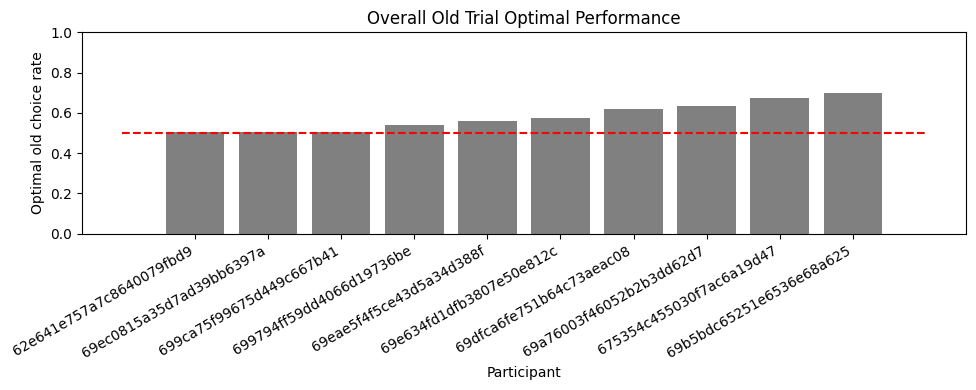

In [12]:
# plot each subject's overall old optimal performance, sorted low to high
old_trials_df = df.query('old_trial == 1').copy()
plot_df = old_trials_df.groupby('participant_id', as_index=False).agg({'optimal_old_choice': 'mean'})
plot_df = plot_df.sort_values('optimal_old_choice').reset_index(drop=True)
plot_df['x'] = np.arange(len(plot_df))

plt.figure(figsize=(10, 4))
sns.barplot(x='x', y='optimal_old_choice', data=plot_df, color='gray')
plt.title('Overall Old Trial Optimal Performance')
plt.xlabel('Participant')
plt.ylabel('Optimal old choice rate')
plt.xticks(plot_df['x'], plot_df['participant_id'], rotation=30, ha='right')
plt.hlines(y=0.5,xmin=-1,xmax=len(plot_df),linestyles='dashed',colors='red')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [4]:
# print out list of all participant_id,final_bonus
bonus_df = df.groupby('participant_id', as_index=False).agg({'final_bonus': 'max'})
bonus_df = bonus_df.sort_values('participant_id')
print('For bonus payment: ')
for i,row in bonus_df.iterrows():
    print(f'{row.participant_id},{row.final_bonus}')


For bonus payment: 
62e641e757a7c8640079fbd9,0.6
675354c455030f7ac6a19d47,1.4
699794ff59dd4066d19736be,1.0
699ca75f99675d449c667b41,0.8
69a76003f46052b2b3dd62d7,1.2
69b5bdc65251e6536e68a625,0.6
69dfca6fe751b64c73aeac08,1.0
69e634fd1dfb3807e50e812c,1.4
69eae5f4f5ce43d5a34d388f,0.6
69ec0815a35d7ad39bb6397a,1.0


# Old Trial Performance

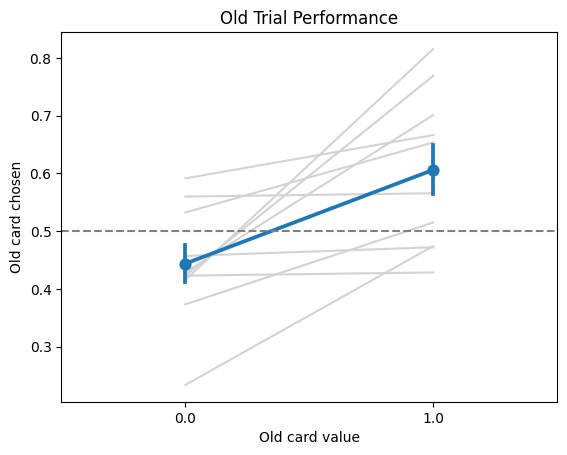

In [14]:
# average + error bars, with subject points + connecting lines in light gray behind
old_trials_df = df.query('old_trial == 1').copy()
plot_df = old_trials_df.groupby(['participant_id', 'old_value'], as_index=False).agg({'old_chosen': 'mean'})



sns.lineplot(x='old_value', y='old_chosen', units='participant_id', estimator=None, data=plot_df, color='lightgray')
sns.pointplot(x='old_value', y='old_chosen', data=plot_df, errorbar='se', color='tab:blue') # mean
plt.title('Old Trial Performance')
plt.ylabel('Old card chosen')
plt.xlabel('Old card value')
plt.hlines(y=0.5,xmin=-0.5,xmax=1.5,linestyles='dashed',colors='gray')
plt.xlim(-0.5,1.5)
plt.show()


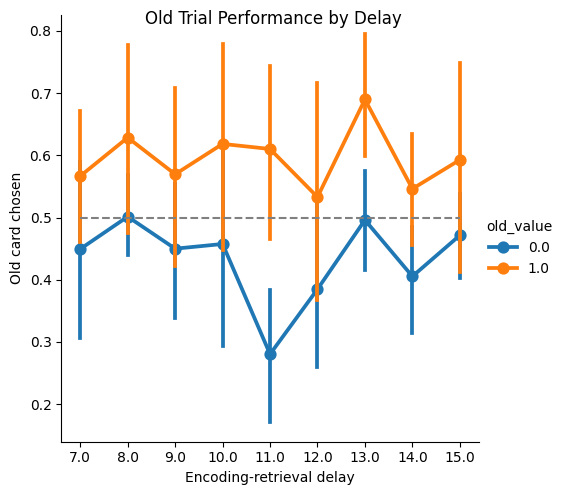

In [22]:
plot_df = df.groupby(['participant_id', 'delay', 'old_value'], as_index=False).agg({'old_chosen': 'mean'})
sns.catplot(x='delay', y='old_chosen', hue='old_value', data = plot_df, kind='point')
plt.suptitle('Old Trial Performance by Delay')
plt.ylabel('Old card chosen')
plt.xlabel('Encoding-retrieval delay')
plt.hlines(y=0.5,xmin=0,xmax=8,linestyles='dashed',colors='gray')
plt.show()

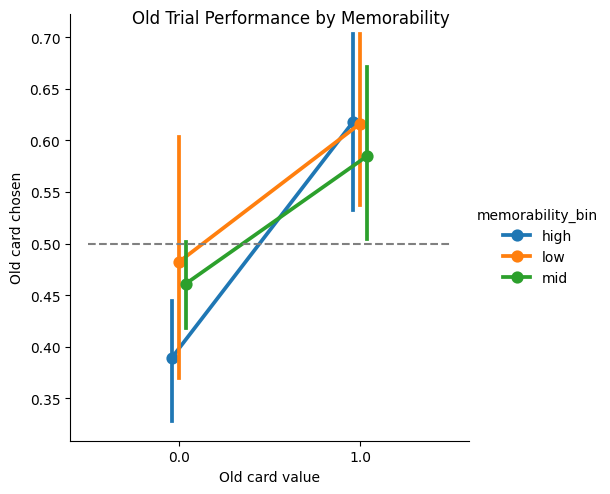

In [23]:
plot_df = df.groupby(['participant_id', 'memorability_bin', 'old_value'], as_index=False).agg({'old_chosen': 'mean'})
sns.catplot(hue='memorability_bin', y='old_chosen', x='old_value', data = plot_df, kind='point', dodge=True)
plt.suptitle('Old Trial Performance by Memorability')
plt.ylabel('Old card chosen')
plt.xlabel('Old card value')
plt.hlines(y=0.5,xmin=-0.5,xmax=1.5,linestyles='dashed',colors='gray')
plt.show()

# RT

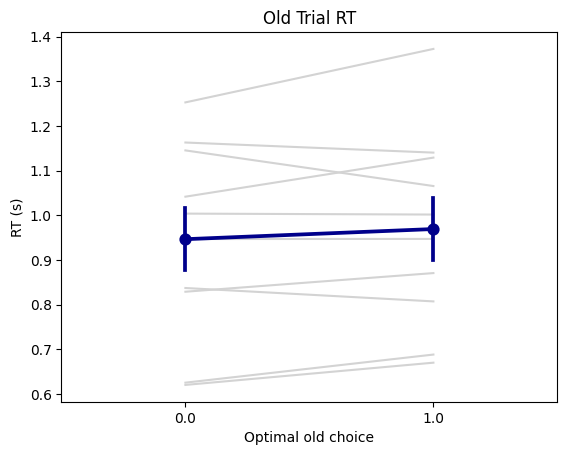

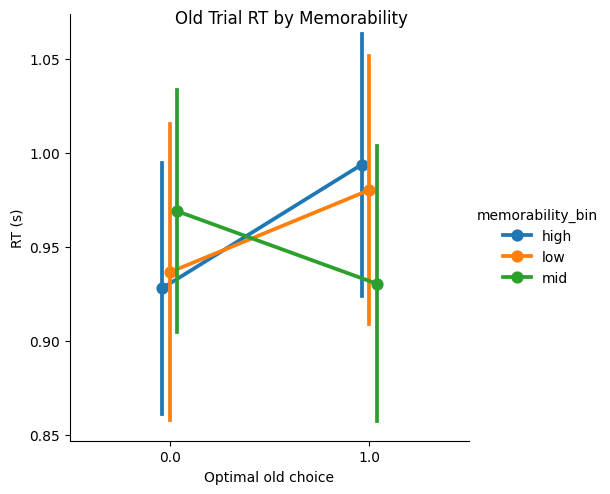

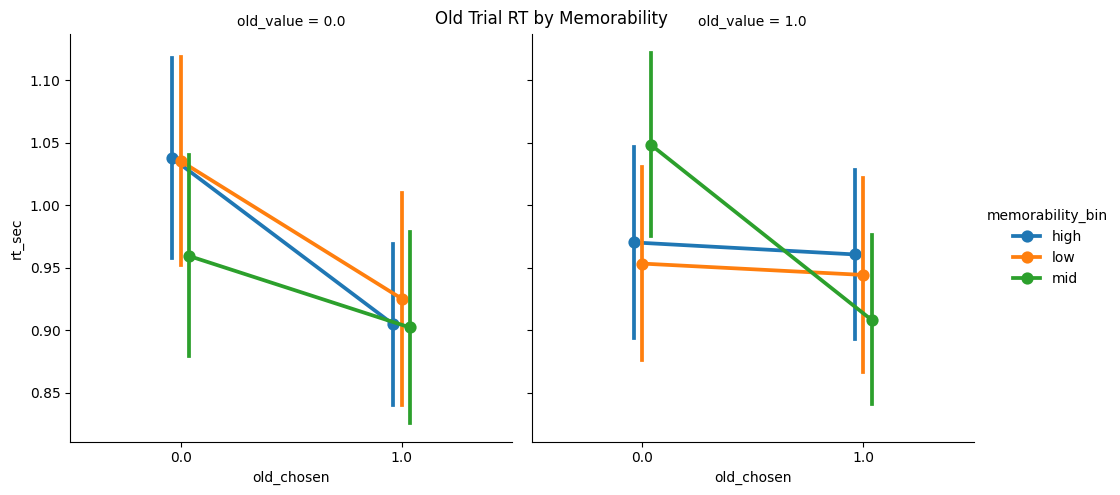

In [8]:

# repeat old trial performance + old trial performance by memorability plots, but for RT instead of old_chosen
old_trials_df = df.query('old_trial == 1').copy()
old_trials_df['rt_sec'] = old_trials_df['rt'] / 1000

plot_df = old_trials_df.groupby(['participant_id', 'optimal_old_choice'], as_index=False).agg({'rt_sec': 'mean'})
sns.lineplot(x='optimal_old_choice', y='rt_sec', units='participant_id', estimator=None,
             data=plot_df, color='lightgray')

sns.pointplot(x='optimal_old_choice', y='rt_sec', data=plot_df, errorbar='se', color='darkblue')
plt.title('Old Trial RT')
plt.ylabel('RT (s)')
plt.xlabel('Optimal old choice')
plt.show()

plot_df = old_trials_df.groupby(['participant_id', 'memorability_bin', 'optimal_old_choice'], as_index=False).agg({'rt_sec': 'mean'})
sns.catplot(hue='memorability_bin', y='rt_sec', x='optimal_old_choice', data=plot_df, kind='point', errorbar='se', dodge=True)
plt.suptitle('Old Trial RT by Memorability')
plt.ylabel('RT (s)')
plt.xlabel('Optimal old choice')
plt.show()

plot_df = old_trials_df.groupby(['participant_id', 'memorability_bin', 'old_chosen', 'old_value'], as_index=False).agg({'rt_sec': 'mean'})
sns.catplot(hue='memorability_bin', y='rt_sec', x='old_chosen', col='old_value', data=plot_df, kind='point', errorbar='se', dodge=True)
plt.suptitle('Old Trial RT by Memorability')
plt.ylabel('RT (s)')
plt.show()


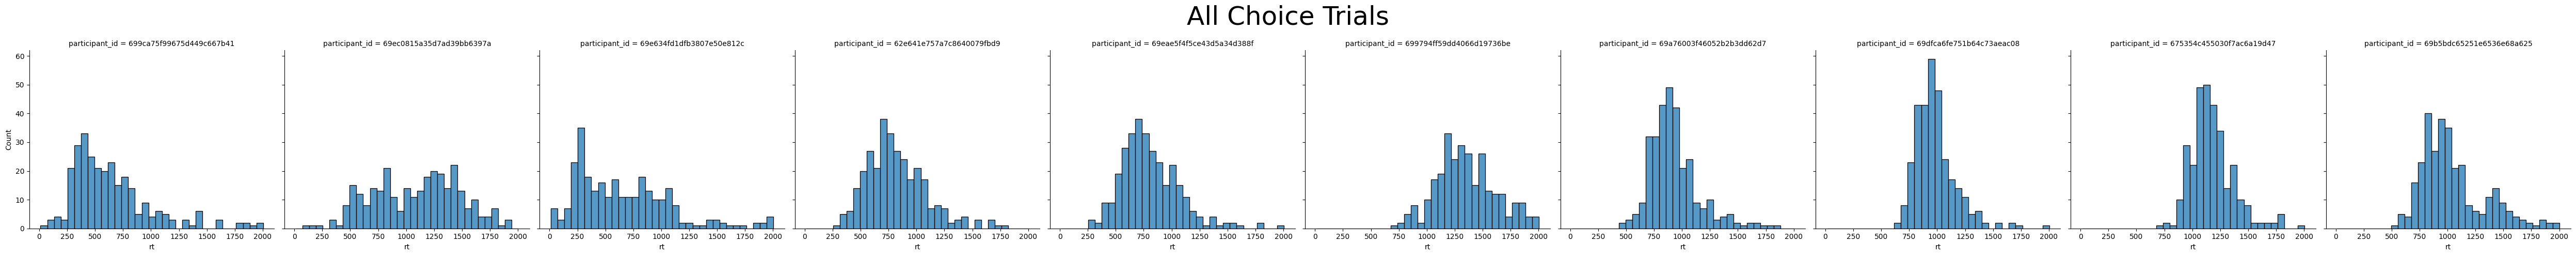

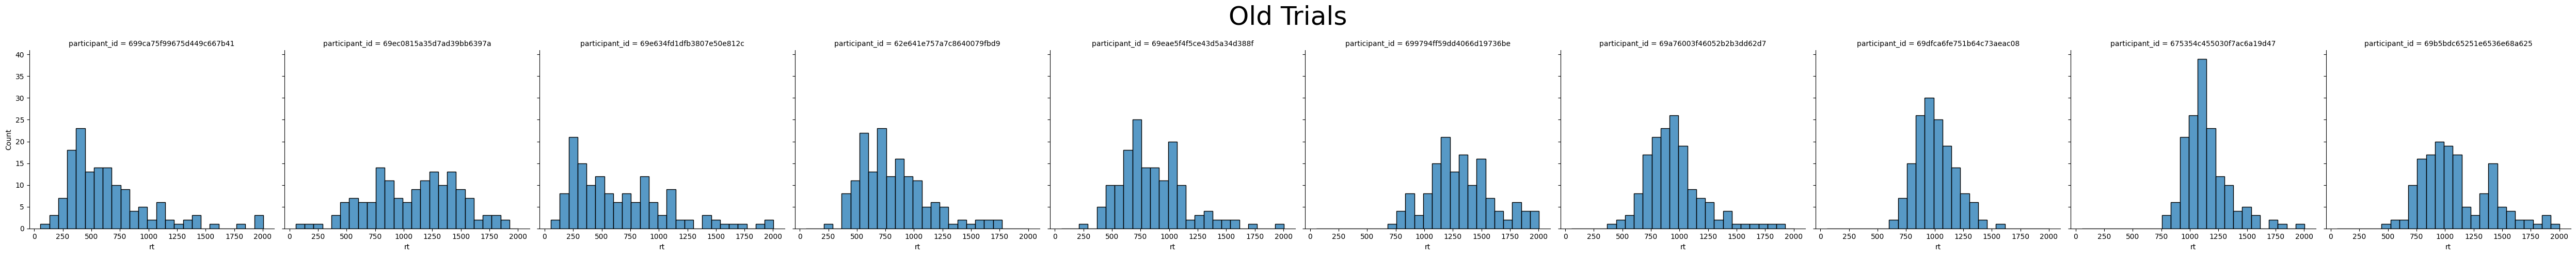

In [9]:
sns.displot(x='rt', data=df.query('is_choice_trial==True'), col='participant_id')
plt.suptitle('All Choice Trials',fontsize=36)
plt.tight_layout()
plt.show()

sns.displot(x='rt', data=df.query('old_trial==1'), col='participant_id')
plt.suptitle('Old Trials',fontsize=36)
plt.tight_layout()
plt.show()

# Attention Checks

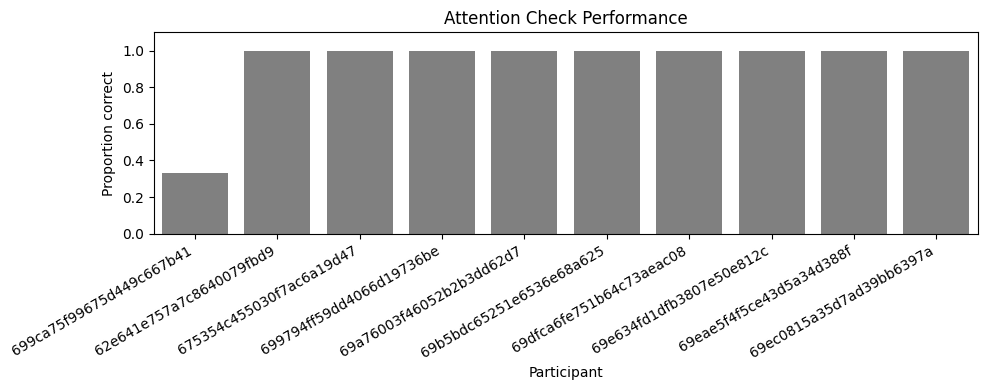

In [10]:

# plot attention check performance per subject
# participant_id is the label, and then a bar for attention check performance
attention_df = df.query('is_attention_check == True').copy()
plot_df = attention_df.groupby('participant_id', as_index=False).agg({'correct': 'mean'})
plot_df = plot_df.sort_values('correct').reset_index(drop=True)
plot_df['x'] = np.arange(len(plot_df))

plt.figure(figsize=(10, 4))
sns.barplot(x='x', y='correct', data=plot_df, color='gray')
plt.title('Attention Check Performance')
plt.ylabel('Proportion correct')
plt.xlabel('Participant')
plt.xticks(plot_df['x'], plot_df['participant_id'], rotation=30, ha='right')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


In [11]:
# did anyone respond with space bar on the attention checks? (white text LLM check)
attention_df = df.query('is_attention_check == True').copy()
space_df = attention_df.query('response_key == " " or response == " "')

print(f'{len(space_df)} space-bar responses on attention checks')
space_df[['participant_id', 'trial_number', 'response', 'response_key', 'correct']]


0 space-bar responses on attention checks


,participant_id,trial_number,response,response_key,correct
